# InChI and tokenized InChI db Exploratory Data Analysis (EDA)

## Load InChI dataset

Reads the pre‑computed InChI strings from `inchi_output.txt` (tab‑separated, one InChI per line) into a pandas DataFrame with a single column `"InChI"`.  

The `db.head()` call displays the first few rows to verify the data loaded correctly.  

In [1]:
import pandas as pd
import os
from tokenizers import ByteLevelBPETokenizer
from transformers import PreTrainedTokenizerFast

# Add the parent directory (repository root) to sys.path
script_dir = '.'   # current directory (where the notebook is running)
inchi_file = os.path.join(script_dir, "inchi_output.txt")
db = pd.read_csv(inchi_file, header=None, names=["InChI"], sep="\t")
db_smiles = pd.read_csv(os.path.join(script_dir, "smiles_chembl.smi"), header=None, names = ["SMILES", "ChEMBL_ID"], sep="\t")

db.head()
db_smiles.head()

c:\Users\grobl\anaconda3\envs\IMF-Master\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,SMILES,ChEMBL_ID
0,CCO,CHEMBL545
1,C,CHEMBL17564
2,CO,CHEMBL14688
3,NCCS,CHEMBL602
4,NCCN,CHEMBL816


## Raw InChI Statistics: Sequence Length Distribution

Before analysing the tokenized representation, it is necessary to characterise the raw InChI strings that constitute the input corpus. This step provides a direct view of the structural complexity and variability of the data prior to any transformation.

In particular, the distribution of sequence lengths (in characters) allows us to:

* quantify the scale and variability of molecular representations,
* identify extreme cases (especially very long molecules),
* and establish a baseline for later decisions in the tokenization and modeling pipeline (e.g., maximum sequence length constraints).

The following snippet computes key descriptive statistics, including central tendency and high-percentile values, to capture both typical and tail behaviour of the dataset.

In [115]:
import numpy as np

# --- Compute InChI length percentiles ---
def compute_inchi_length_percentiles():
    lengths = []
    with open(inchi_file, 'r') as f:
        for i, line in enumerate(f):
            token_count = len(line)
            lengths.append(token_count)

    # Convert to numpy array for percentile calculation
    lengths_np = np.array(lengths)
    percentiles = [1, 50, 75, 90, 99, 99.9]
    p = np.percentile(lengths_np, percentiles)
    print(f"\n--- InChI Length Statistics ---")
    print(f"Total sequences: {len(lengths)}")
    print(f"Mean length: {np.mean(lengths_np):.2f}")
    print(f"Median: {np.median(lengths_np)}")
    print(f"Max length: {np.max(lengths_np)}")
    print(f"Min length: {np.min(lengths_np)}")
    for perc, val in zip(percentiles, p):
        print(f"{perc}th percentile: {val}")

compute_inchi_length_percentiles()


--- InChI Length Statistics ---
Total sequences: 1575727
Mean length: 149.60
Median: 136.0
Max length: 3916
Min length: 17
1th percentile: 67.0
50th percentile: 136.0
75th percentile: 163.0
90th percentile: 196.0
99th percentile: 443.0
99.9th percentile: 1500.0


### Interpretation
The length distribution shows a relatively compact central mass (median = 136, mean ≈ 150), but with a pronounced **right-skewed tail**, where a small fraction of molecules reach very large sizes (up to 3916 characters). This is reflected in the sharp increase between the 99th percentile (443) and the 99.9th percentile (1500), indicating that most of the variance is concentrated in the extreme upper tail rather than in the bulk of the data.

From a modeling perspective, setting a maximum sequence length of **512 tokens** is a well-justified compromise. It fully covers **more than 99% of the dataset without truncation**, while only affecting a very small subset of unusually large molecules. 

Mean length: 148.60
Variance: 8519.09


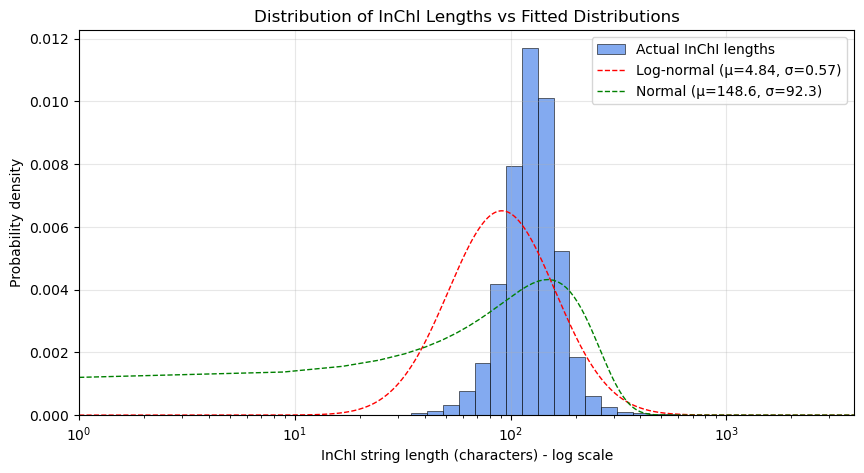

In [96]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import lognorm, norm, nbinom

# Extract lengths (number of characters) of each InChI string
lengths = db["InChI"].str.len()

# Compute mean and variance
mean_len = lengths.mean()
var_len = lengths.var()
print(f"Mean length: {mean_len:.2f}")
print(f"Variance: {var_len:.2f}")

# --- Log‑normal (red) ---
sigma_sq = np.log(1 + var_len / (mean_len**2))
sigma = np.sqrt(sigma_sq)
mu = np.log(mean_len) - sigma_sq / 2

# --- Normal distribution (green) ---
# Parameters: mean and standard deviation
norm_mean = mean_len
norm_std = np.sqrt(var_len)

# Create bins from 1 to max length, log‑spaced
bins = np.logspace(0, np.log10(lengths.max()), num=50)

plt.figure(figsize=(10,5))
plt.hist(lengths, bins=bins, density=True, alpha=0.8,
         edgecolor='black', linewidth=0.5,
         color='cornflowerblue', label='Actual InChI lengths')

# X values for smooth curves (linear spaced in log domain)
x_lin = np.linspace(1, lengths.max(), 500)
x_log = np.logspace(0, np.log10(lengths.max()), 500)

# Log‑normal PDF (red dashed)
pdf_lognorm = lognorm.pdf(x_log, s=sigma, scale=np.exp(mu))
plt.plot(x_log, pdf_lognorm, 'r--', linewidth=1,
         label=f'Log‑normal (μ={mu:.2f}, σ={sigma:.2f})')

# Normal PDF (green dashed)
pdf_norm = norm.pdf(x_lin, loc=norm_mean, scale=norm_std)
plt.plot(x_lin, pdf_norm, 'g--', linewidth=1,
         label=f'Normal (μ={norm_mean:.1f}, σ={norm_std:.1f})')


plt.xscale('log')
plt.xlim(1, lengths.max())
plt.xlabel('InChI string length (characters) - log scale')
plt.ylabel('Probability density')
plt.title('Distribution of InChI Lengths vs Fitted Distributions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Figure interpretation

xxx

### Layering and Stereochemistry
Beyond sequence length, it is useful to examine basic structural properties encoded within the InChI strings. InChI representations are inherently hierarchical, with different layers (separated by “/”) encoding connectivity, hydrogen atoms, stereochemistry, and other chemical features.

This analysis focuses on two aspects:

* average number of structural layers, as a proxy for representation complexity, and
* the presence of stereochemical information, which is critical for certain biochemical processes.

In particular, the proportion of molecules containing stereochemistry is monitored, as unexpectedly low values may indicate limitations in the upstream representation or data processing. This observation will be revisited later when discussing potential implications for modeling.

Unique characters - good for bpe or needs to check for unique tokens?

In [ ]:
def analyze_inchi_structure(inchi):
    return {
        "length": len(inchi),
        "num_layers": inchi.count("/"),
        "has_stereo": int("/t" in inchi or "/m" in inchi or "/b" in inchi or "/s" in inchi),
    }
total = len(db)
num_layers = 0
has_stereo_count = 0
for i in db["InChI"]:
    struct = analyze_inchi_structure(i)
    num_layers += struct["num_layers"]
    has_stereo_count += struct["has_stereo"]

print(f"\n--- InChI Structural Analysis ---")
print(f"Average number of layers: {num_layers / total:.2f}")
print(f"Percentage of InChIs with stereochemistry: {has_stereo_count / total * 100:.2f}%")
print(f"Total stereochemistry entries: {has_stereo_count}")


--- InChI Structural Analysis ---
Average number of layers: 3.01
Percentage of InChIs with stereochemistry: 0.01%
Total stereochemistry entries: 93


### Alphabet size
 The number of unique characters provides a direct indication of the **alphabet size** of the InChI representation, which in this case is relatively small (35 characters). This limited makes it well-suited for subword tokenization methods such as BPE. BPE is justified in this case because it can efficiently capture recurring patterns and substrings within this constrained alphabet, improving representation without requiring a large base vocabulary.

In [ ]:
unique_chars = set("".join(db["InChI"]))
print(f"Number of unique characters: {len(unique_chars)}")

Number of unique characters: 35


## DUplicates

In [ ]:
def analyze_duplicates(df, df_smiles):
    dup_inchi = df.duplicated(subset="InChI").sum()
    dup_smiles = df_smiles.duplicated(subset="SMILES").sum()

    total = len(df)
    print(f"\n--- Duplicate Analysis ---")
    print(f"InChI duplicates: {dup_inchi} ({dup_inchi/total:.2%})")
    print(f"SMILES duplicates: {dup_smiles} ({dup_smiles/total:.2%})")

    unique_ratio = (total - dup_inchi) / total
    print(f"Unique molecule ratio: {unique_ratio:.4f}")
    print(f"Unique molecules: {total - dup_inchi:,} out of {total:,}")

    print("\n--- Multiplicity ---")
    print(f"Max duplicates (InChI): {df['InChI'].value_counts().max()}")
    print(f"Max duplicates (SMILES): {df_smiles['SMILES'].value_counts().max()}")

analyze_duplicates(db, db_smiles)


--- Duplicate Analysis ---
InChI duplicates: 73565 (4.67%)
SMILES duplicates: 73232 (4.65%)
Unique molecule ratio: 0.9533
Unique molecules: 1,502,162 out of 1,575,727

--- Multiplicity ---
Max duplicates (InChI): 510
Max duplicates (SMILES): 510


Check if the duplicates came from the SMILES data set or if they were introduced due to no stereochemistry

In [ ]:
# Find SMILES with maximum duplication
dup_counts = db_smiles["SMILES"].value_counts()

max_count = dup_counts.max()
most_duplicated_smiles = dup_counts[dup_counts == max_count]
print(f"Max duplication count: {max_count}")

Max duplication count: 510


In [ ]:
# Inspect a few of the most duplicated SMILES
top_n = 5
print(f"\nTop {top_n} duplicated SMILES (count then SMILES):")
for smi, count in dup_counts.head(top_n).items():
    print(f"{count}: {smi}")


Top 5 duplicated SMILES (count then SMILES):
510: CSCCC(NC(=O)C(CC(C)C)NC(=O)CNC(=O)C(Cc1ccccc1)NC(=O)C(Cc1ccccc1)NC(=O)C(CCC(N)=O)NC(=O)C(CCC(N)=O)NC(=O)C1CCCN1C(=O)C(CCCCN)NC(=O)C1CCCN1C(=O)C(N)CCCN=C(N)N)C(N)=O
32: CSCCC(NC(=O)C(CCC(N)=O)NC(=O)C(N)Cc1c[nH]c2ccccc12)C(=O)NCC(=O)NC(Cc1c[nH]cn1)C(=O)NC(CO)C(O)=O
30: CCCCCCCCCCCCNC(=O)C1CC(=O)NC(CO)C(=O)NC(Cc2ccc(O)cc2)C(=O)NC(CC(N)=O)C(=O)NCC(=O)NC(CC(N)=O)C(=O)NC(CO)C(=O)NC(CC(N)=O)C(=O)N1
24: CCC(C)C(NC(=O)C(CC(C)C)NC(=O)C(NC(=O)C(N)CCSC)C(C)O)C(=O)NCC(=O)NC(C)C(=O)NC(C)C(=O)NC(Cc1c[nH]cn1)C(=O)NC(CC(N)=O)C(=O)NCC(=O)NC(CO)C(=O)NC(C)C(=O)NC(CCC(N)=O)C(=O)NC(CC(C)C)C(=O)NC(CC(C)C)C(=O)NC(CCCN=C(N)N)C(=O)NC(CCC(N)=O)C(=O)NC(CC(C)C)C(=O)NC(CCCN=C(N)N)C(=O)NCC(=O)NC(CCC(N)=O)C(=O)NC(CC(C)C)C(=O)NCC(=O)N1CCCC1C(=O)N1CCCC1C(=O)NCC(=O)NC(CO)C(=O)NC(CCCN=C(N)N)C(N)=O
21: CCC(C)C(C(CC(=O)N1CCCC1C(OC)C(C)C(=O)NC(Cc1ccccc1)c1nccs1)OC)N(C)C(=O)C(NC(=O)C(C(C)C)N(C)C)C(C)C


NO hay stereoquimica ya que \ en los string de smiles dan error por escape character (esto es para estereiquimica de doble bond trans) mientras que si que hay para los cis ya que usan solo / y no \. Tampoco hay R o S ya que ninguna SMILES usa @. Bias en contra de stereoquimica, potencial caveat. 

## Load ByteLevelBPETokenizer

Loads the pre‑trained tokenizer from the saved `vocab.json` and `merges.txt` files located in the `inchi_tokenizer/` subdirectory.  
The tokenizer was previously trained on a large InChI corpus and will be used to encode InChI strings into token IDs.

In [2]:
from tokenizers import ByteLevelBPETokenizer
import os
# Load the pre-trained ByteLevelBPETokenizer from the specified vocab and merges files
tokenizer = ByteLevelBPETokenizer(
    vocab=os.path.join(script_dir, "inchi_tokenizer", "vocab.json"),
    merges=os.path.join(script_dir, "inchi_tokenizer", "merges.txt"))
print("Loaded ByteLevelBPETokenizer")

Loaded ByteLevelBPETokenizer


## Tokenize all InChI strings

In order to be able to execute the analysis also on the tokenized strings parallel to the raw InChI, we pre-tokenize all InChI strings in our `main()` function.

This function runs the tokenizer over every InChI stored in the database (`db`).  
The pre‑trained **ByteLevelBPETokenizer** (loaded from `inchi_tokenizer/vocab.json` and `inchi_tokenizer/merges.txt`) encodes each InChI into a list of token IDs.  

The output is saved as `inchi_tokens.txt` (one line per InChI, space‑separated token IDs).  
Progress is printed every 100,000 entries.  

This is a **one‑time preprocessing step**; subsequent analysis (e.g., token length statistics, verification) reads the cached file rather than re‑encoding the entire corpus.  

The `main()` function is currently commented out in the script. Uncomment it if if is needed to regenerate the tokenized file.

In [3]:
def main():
    output_file = os.path.join(script_dir, "inchi_tokens.txt")
    total = len(db)
    print(f"Starting tokenization of {total} InChIs...")
    with open(output_file, 'w', encoding='utf-8') as f_out:
        for i, inchi in enumerate(db["InChI"]):
            encoded = tokenizer.encode(inchi)
            token_ids = encoded.ids
            f_out.write(" ".join(map(str, token_ids)) + "\n")
            if (i + 1) % 100000 == 0:
                print(f"Processed {i+1}/{total} InChIs")
    print(f"Tokenization complete. Output saved to {output_file}")

with open("inchi_tokens.txt", "r") as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(line.strip())

281 33 21 55 19 39 22 44 26 51 19 71 21 17 22 17 23 19 76 23 44 16 22 44 22 16 21 44 23
281 33 21 55 19 783 24 19 76 21 44 24
281 33 21 55 19 783 24 51 19 71 21 17 22 19 76 22 44 16 21 44 23
281 33 21 55 19 39 22 44 27 582 19 71 23 17 21 17 22 17 24 19 76 24 44 16 21 17 23 44 22
281 33 21 55 19 39 22 44 28 50 22 19 71 23 17 21 17 22 17 24 19 76 21 17 24 44 22


# EDA of tokenized sequences

## Tokenizer efficiency: Characters per token

In [ ]:
# --- Count total tokens ---
total_tokens = 0
with open("inchi_tokens.txt", "r") as f:
    for line in f:
        total_tokens += len(line.split())

# --- Count total characters ---
total_chars = 0
with open(inchi_file, "r") as f:
    for line in f:
        total_chars += len(line.strip())

# --- Compute averages ---
num_sequences = sum(1 for _ in open(inchi_file))
avg_chars = total_chars / num_sequences
avg_tokens = total_tokens / num_sequences

# --- Compute ratio ---
chars_per_token = total_chars / total_tokens

print("\n=== Tokenization Summary ===")
print(f"Average characters per sequence: {avg_chars:.3f}")
print(f"Average tokens per sequence: {avg_tokens:.3f}")
print(f"Characters per token: {chars_per_token:.3f}")


=== Tokenization Summary ===
Average characters per sequence: 148.603
Average tokens per sequence: 109.739
Characters per token: 1.354


## Percentiles token


In [ ]:
# --- Compute token length percentiles ---
def compute_token_length_percentiles():
    tokens_file = os.path.join(script_dir, "inchi_tokens.txt")

    lengths = []
    with open(tokens_file, 'r') as f:
        for i, line in enumerate(f):
            token_count = len(line.split())
            lengths.append(token_count)

    # Convert to numpy array for percentile calculation
    lengths_np = np.array(lengths)
    percentiles = [1, 50, 75, 90, 99, 99.9]
    p = np.percentile(lengths_np, percentiles)
    print(f"\n--- Token Length Statistics ---")
    print(f"Total sequences: {len(lengths)}")
    print(f"Mean length: {np.mean(lengths_np):.2f}")
    print(f"Median: {np.median(lengths_np)}")
    print(f"Max length: {np.max(lengths_np)}")
    print(f"Min length: {np.min(lengths_np)}")
    for perc, val in zip(percentiles, p):
        print(f"{perc}th percentile: {val}")

compute_token_length_percentiles()


--- Token Length Statistics ---
Total sequences: 1575727
Mean length: 109.74
Median: 102.0
Max length: 2068
Min length: 11
1th percentile: 55.0
50th percentile: 102.0
75th percentile: 119.0
90th percentile: 142.0
99th percentile: 305.0
99.9th percentile: 844.0


In [113]:
tokens_file = os.path.join(script_dir, "inchi_tokens.txt")
db_tokens = pd.read_csv(tokens_file, header=None, names=["Tokens"], sep="\t")
# Extract lengths (number of characters) of each token string
lengths = db_tokens["Tokens"].str.split().str.len()

Mean length: 109.74
Variance: 2947.78


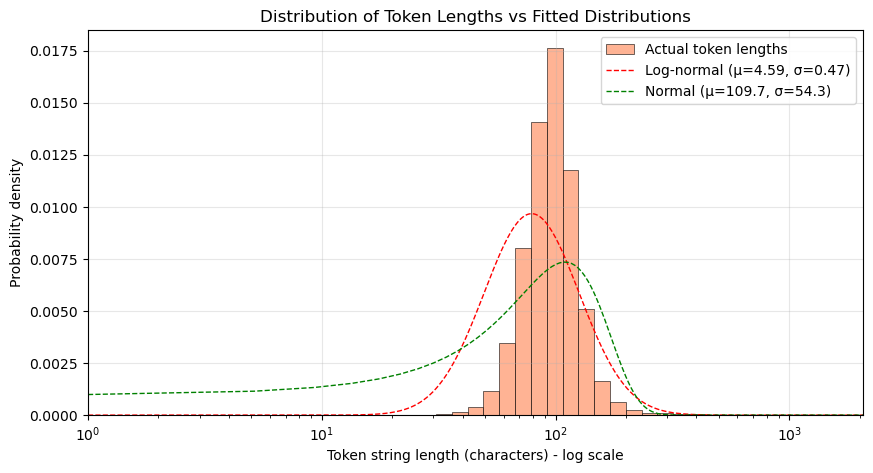

In [114]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import lognorm, norm, nbinom

# Compute mean and variance
mean_len = lengths.mean()
var_len = lengths.var()
print(f"Mean length: {mean_len:.2f}")
print(f"Variance: {var_len:.2f}")

# --- Log‑normal (red) ---
sigma_sq = np.log(1 + var_len / (mean_len**2))
sigma = np.sqrt(sigma_sq)
mu = np.log(mean_len) - sigma_sq / 2

# --- Normal distribution (green) ---
# Parameters: mean and standard deviation
norm_mean = mean_len
norm_std = np.sqrt(var_len)

# Create bins from 1 to max length, log‑spaced
bins = np.logspace(0, np.log10(lengths.max()), num=50)

plt.figure(figsize=(10,5))
plt.hist(lengths, bins=bins, density=True, alpha=0.8,
         edgecolor='black', linewidth=0.5,
         color='lightsalmon', label='Actual token lengths')

# X values for smooth curves (linear spaced in log domain)
x_lin = np.linspace(1, lengths.max(), 500)
x_log = np.logspace(0, np.log10(lengths.max()), 500)

# Log‑normal PDF (red dashed)
pdf_lognorm = lognorm.pdf(x_log, s=sigma, scale=np.exp(mu))
plt.plot(x_log, pdf_lognorm, 'r--', linewidth=1,
         label=f'Log‑normal (μ={mu:.2f}, σ={sigma:.2f})')

# Normal PDF (green dashed)
pdf_norm = norm.pdf(x_lin, loc=norm_mean, scale=norm_std)
plt.plot(x_lin, pdf_norm, 'g--', linewidth=1,
         label=f'Normal (μ={norm_mean:.1f}, σ={norm_std:.1f})')


plt.xscale('log')
plt.xlim(1, lengths.max())
plt.xlabel('Token string length (characters) - log scale')
plt.ylabel('Probability density')
plt.title('Distribution of Token Lengths vs Fitted Distributions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Outlier analysis: Longest InChI string

In [ ]:
# --- Max raw string length ---
max_str_len = max(db["InChI"].apply(len))
print(f"Longest InChI (characters): {max_str_len}")

# --- Find the InChI with maximum string length and tokenize it ---
# Get the actual string
longest_inchi = db.loc[db["InChI"].str.len().idxmax(), "InChI"]

# Tokenize
encoded = tokenizer.encode(longest_inchi)
token_len = len(encoded.ids)
print(f"Longest InChI tokenized length: {token_len} tokens")
print(f"Sample tokens: {encoded.tokens[:15]}...")  # show first 15
compression_ratio = max_str_len / token_len
print(f"Characters per token ratio: {compression_ratio:.4f}")

Longest InChI (characters): 3915
Longest InChI tokenized length: 2068 tokens
Sample tokens: ['InChI', '=', '1', 'S', '/', 'C', '325', 'H', '387', 'N', '118', 'O', '209', 'P', '29']...
Characters per token ratio: 1.8931


In [49]:
from collections import Counter

def token_frequency(inchi_tokens_file):
    counter = Counter()
    with open(inchi_tokens_file) as f:
        for line in f:
            counter.update(line.split())
    
    def decode_token(t):
        return tokenizer.decode([int(t)])
    
    top = counter.most_common(5)
    bottom = counter.most_common()[-5:]

    print("\nTop 5 tokens:")
    for t, c in top:
        print(f"'{decode_token(t)}' : {c}")

    print("\nBottom 5 tokens:")
    for t, c in bottom:
        print(f"'{decode_token(t)}' : {c}")
    rare_tokens = [t for t, c in counter.items() if c < 5]
    print(f"Number of rare tokens (count < 5): {len(rare_tokens)}")

token_frequency(os.path.join(script_dir, "inchi_tokens.txt"))


Top 5 tokens:
'-' : 34773281
',' : 11058201
')' : 10963604
'(' : 10011912
'H' : 7377962

Bottom 5 tokens:
'FP' : 2
'FNOP' : 2
'676' : 2
'677' : 2
'0' : 1
Number of rare tokens (count < 5): 36


## Verify tokenizer determinism

This function performs a **random‑sampling verification** to ensure that the cached token IDs (`inchi_tokens.txt`) are consistent with the tokenizer’s current behavior.  

- It selects a random InChI from the dataset, retrieves its saved token IDs, and re‑encodes the same InChI using the tokenizer.  
- The two sets of token IDs are compared; if they match, the tokenizer is confirmed to produce deterministic output and the cached file is correctly aligned.  

This check addresses the inherent “black‑box” nature of tokenization pipelines, providing an empirical guarantee that the pre‑processed data can be reliably reused without silent inconsistencies.

In [ ]:
import random
# --- Verification: compare a random line from saved file with fresh encoding ---
# --- Run as many times as needed to check different random lines ---
def verify_saved_tokens_random():
    tokens_file = os.path.join(script_dir, "inchi_tokens.txt")
    if not os.path.exists(tokens_file):
        print(f"Error: {tokens_file} not found.")
        return

    # Read all lines to count them and pick a random line
    with open(tokens_file, 'r') as f:
        lines = f.readlines()
    total_lines = len(lines)

    # Pick a random line number (1‑based)
    line_number = random.randint(1, total_lines)
    saved_ids = list(map(int, lines[line_number-1].strip().split()))

    # Get the original InChI from the dataframe (0‑based index)
    original_inchi = db.iloc[line_number-1]["InChI"]

    # Freshly encode the original InChI
    fresh_encoded = tokenizer.encode(original_inchi)
    fresh_ids = fresh_encoded.ids

    # Decode the saved IDs back to a string
    decoded_str = tokenizer.decode(saved_ids)

    print(f"=== Verification for random line {line_number} (of {total_lines}) ===")
    print(f"Original InChI        : {original_inchi}")
    print(f"Decoded from saved IDs: {decoded_str}")
    print(f"Token IDs match       : {saved_ids == fresh_ids}")

    if saved_ids != fresh_ids:
        print("\nMismatch details:")
        print(f"Saved IDs : {saved_ids}")
        print(f"Fresh IDs : {fresh_ids}")
        print(f"Saved tokens : {tokenizer.decode(saved_ids, skip_special_tokens=False)}")
        print(f"Fresh tokens : {tokenizer.decode(fresh_ids, skip_special_tokens=False)}")
    else:
        print("Verification passed: saved tokens match fresh encoding.")

verify_saved_tokens_random()

=== Verification for random line 673089 (of 1575727) ===
Original InChI        : InChI=1S/C19H24N2O6/c1-4-25-18(23)17-13(3)20-19(24)21-14(17)11-27-16(22)9-10-26-15-8-6-5-7-12(15)2/h5-8,13H,4,9-11H2,1-3H3,(H2,20,21,24)
Decoded from saved IDs: InChI=1S/C19H24N2O6/c1-4-25-18(23)17-13(3)20-19(24)21-14(17)11-27-16(22)9-10-26-15-8-6-5-7-12(15)2/h5-8,13H,4,9-11H2,1-3H3,(H2,20,21,24)
Token IDs match       : True
Verification passed: saved tokens match fresh encoding.
